<a href="https://colab.research.google.com/github/Frabat/CS_6795_Appraisal_Notebook/blob/main/Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset
file_path = '/content/drive/MyDrive/CogSci_Reddit_2025_Dump/mlx_annotated_results_v2.csv'

try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"File {file_path} not found. Please ensure it is uploaded or the path is correct.")
    # Using a dummy dataframe for demonstration if file is missing to avoid stopping the entire workflow
    df = pd.DataFrame({'parse_error': [np.nan, 'error', np.nan], 'score': [10, 5, 100], 'created_utc': [1609459200, 1609459300, 1609459400], 'self_control': [0.5, 0.1, -0.5], 'other_control': [0.1, 0.2, 0.3], 'situational_control': [0, 0, 0], 'novelty': [0, 0, 0], 'effort': [0, 0, 0], 'agency': [0.8, -0.2, 0.5], 'goal_congruence': [0.9, 0.1, -0.9], 'certainty': [1.0, 0.5, 0.8], 'sentiment_score': [0.8, -0.1, 0.5], 'discrete_emotion': ['joy', 'anger', 'sadness']})

# 1. Filter for Quality
initial_rows = len(df)
if 'parse_error' in df.columns:
    df = df[df['parse_error'].isna()].copy()
final_rows = len(df)
retained_percentage = (final_rows / initial_rows) * 100 if initial_rows > 0 else 0
print(f"Percentage of data retained after cleaning parse_error: {retained_percentage:.2f}%")

# 2. Engagement Preprocessing
if 'score' in df.columns:
    df['log_score'] = np.log1p(df['score'])

# 3. Temporal Conversion
if 'created_utc' in df.columns:
    # Assuming created_utc is in seconds. If it's already datetime, errors='ignore' helps.
    df['created_utc'] = pd.to_datetime(df['created_utc'], unit='s', errors='coerce')

# 4. Column Organization
APPRAISAL_COLS = ['self_control', 'other_control', 'situational_control', 'novelty', 'effort', 'agency', 'goal_congruence', 'certainty']
BASELINE_COLS = ['sentiment_score', 'discrete_emotion']

# 5. Initial Validation
display(df.head())

# Ensure APPRAISAL_COLS exist before describing to prevent KeyError
existing_appraisal_cols = [col for col in APPRAISAL_COLS if col in df.columns]
if existing_appraisal_cols:
    display(df[existing_appraisal_cols].describe())
else:
    print("Appraisal columns not found in the dataset.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Percentage of data retained after cleaning parse_error: 99.84%


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Unnamed: 0,subreddit,author_hash,id,link_id,parent_id,score,body,created_utc,anchor_url,...,self_control,other_control,situational_control,novelty,effort,sentiment_score,discrete_emotion,rationale,parse_error,log_score
0,0,democrats,1440ea1b556b,c8iil1d,t3_18vdpw,t3_18vdpw,3,I personally don't understand why people get s...,2013-02-20 17:01:39,http://antiwar.com/blog/2013/02/19/nancy-pelos...,...,0.7,0.9,-0.8,0.2,0.5,-0.8,Disgust,The author is disgusted by the lack of account...,NaN,1.386294
1,1,politics,9ebfe9046c32,cpir1po,t3_2zgkog,t3_2zgkog,60,"The ""most transparent administration in US his...",2015-03-18 14:02:27,http://bigstory.ap.org/article/ab029d7c6251493...,...,-0.9,0.9,-0.9,-0.9,-0.9,-1.0,Anger,The author feels powerless against a powerful ...,NaN,4.110874
2,2,politics,1c31bc3e2a7b,cpirvpk,t3_2zgkog,t1_cpirtl8,37,Yet he goes after whistleblowers at an unprece...,2015-03-18 14:29:51,http://bigstory.ap.org/article/ab029d7c6251493...,...,0.2,0.9,-0.8,0.5,0.8,-0.9,Anger,The author perceives a powerful adversary acti...,NaN,3.637586
3,3,politics,dd744ef7d7a9,cpixzdg,t3_2zgkog,t3_2zgkog,33,"""The only people who don't want to disclose th...",2015-03-18 17:18:07,http://bigstory.ap.org/article/ab029d7c6251493...,...,0.2,0.9,-0.8,0.5,-0.8,-0.9,Anger,The author perceives a powerful adversary (the...,NaN,3.526361
4,4,politics,cbde1724b93a,cpistom,t3_2zgkog,t1_cpirtl8,23,"Hey, if you are sure you censored everything y...",2015-03-18 14:58:11,http://bigstory.ap.org/article/ab029d7c6251493...,...,0.9,0.1,0.5,0.5,0.1,0.9,Sarcastic,The author perceives a moderate level of situa...,NaN,3.178054


,self_control,other_control,situational_control,novelty,effort
count,30329.000000,30329.000000,30329.000000,30321.000000,30329.000000
mean,-0.359953,0.585018,-0.116644,-0.099568,0.272422
std,0.456024,0.414354,0.465034,0.528391,0.215784
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-0.800000,0.100000,-0.400000,-0.500000,0.100000
50%,-0.400000,0.800000,-0.300000,-0.400000,0.200000
75%,-0.200000,0.900000,-0.100000,0.300000,0.400000
max,1.000000,1.000000,1.000000,1.000000,1.000000


### Power and Control Dimensional Analysis

Exploring `self_control`, `other_control`, and `situational_control` across subreddits.

/tmp/ipykernel_5370/1930294576.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='subreddit', y=col, data=df_clean, ax=axes[i], palette='muted', inner='quartile')
/tmp/ipykernel_5370/1930294576.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='subreddit', y=col, data=df_clean, ax=axes[i], palette='muted', inner='quartile')
/tmp/ipykernel_5370/1930294576.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='subreddit', y=col, data=df_clean, ax=axes[i], palette='muted', inner='quartile')


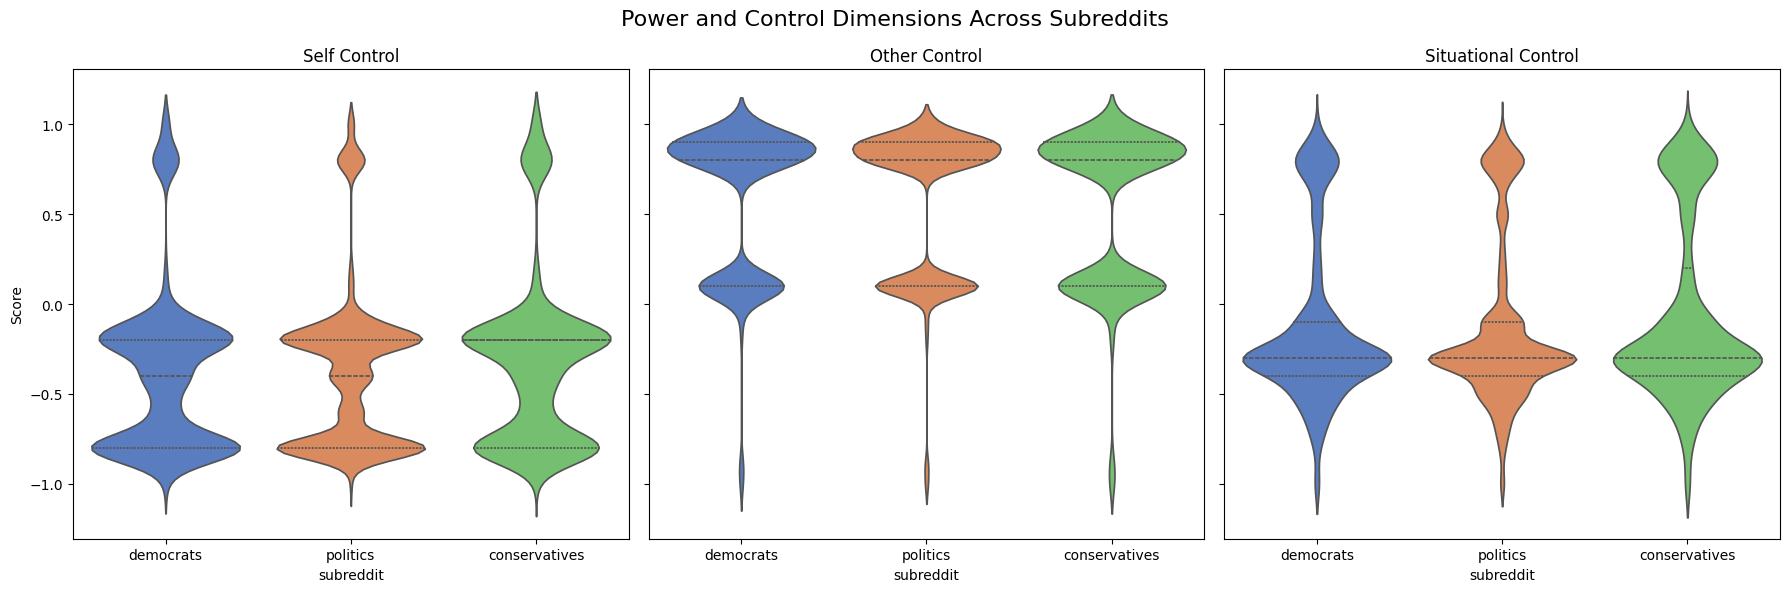

/tmp/ipykernel_5370/1930294576.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='subreddit', y='control_imbalance', data=mean_imbalance, palette='RdBu')


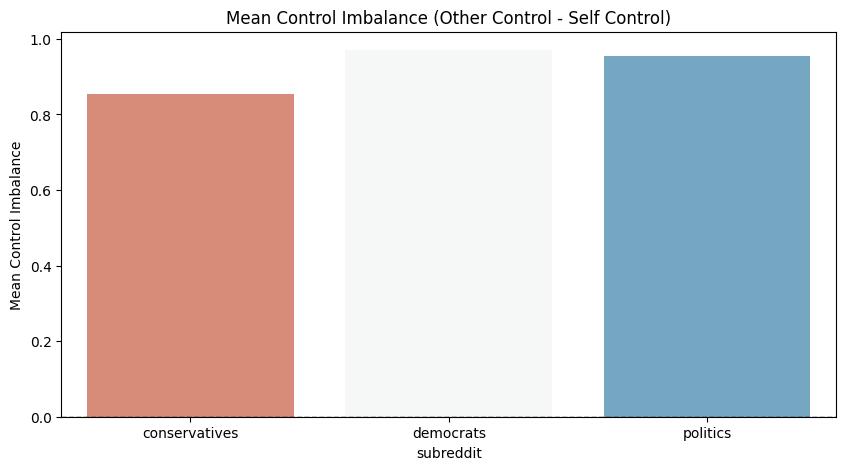


--- Kruskal-Wallis H-test Results ---
Self Control: H-statistic = 43.4387, p-value = 3.6932e-10 (Significant)
Other Control: H-statistic = 58.5384, p-value = 1.9433e-13 (Significant)
Situational Control: H-statistic = 38.6294, p-value = 4.0901e-09 (Significant)


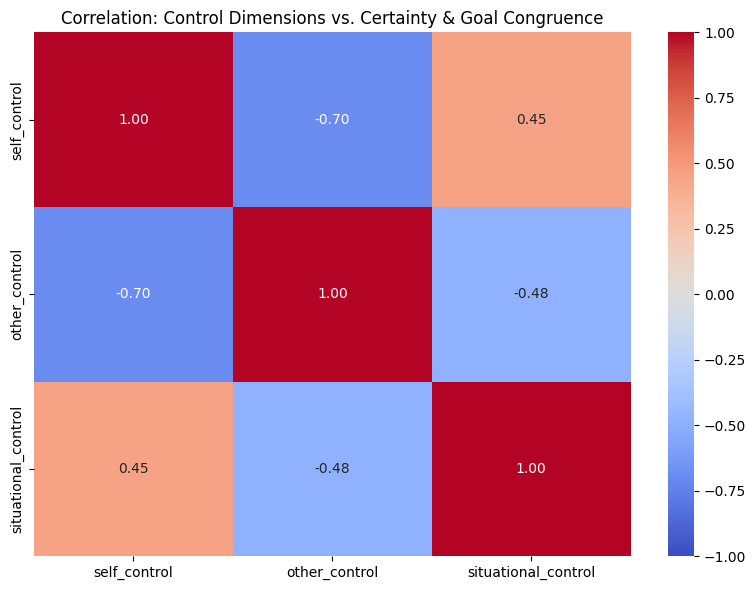


--- Summary Table (Mean and Median) ---


self_control        other_control        situational_control  \
                      mean median          mean median                mean   
subreddit                                                                    
conservatives    -0.318917   -0.2      0.534584    0.8           -0.070554   
democrats        -0.375678   -0.4      0.594732    0.8           -0.117362   
politics         -0.363787   -0.4      0.592093    0.8           -0.125116   

                     control_imbalance         
              median              mean median  
subreddit                                      
conservatives   -0.3          0.853501    1.0  
democrats       -0.3          0.970410    1.0  
politics        -0.3          0.955880    1.0

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal

# Ensure we have a working copy of the dataset
df_clean = df.copy()

# Filter out missing subreddits to be safe
if 'subreddit' in df_clean.columns:
    df_clean = df_clean.dropna(subset=['subreddit'])

# 1. Triad Visualization
control_cols = ['self_control', 'other_control', 'situational_control']
available_controls = [c for c in control_cols if c in df_clean.columns]

if len(available_controls) == 3 and 'subreddit' in df_clean.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    for i, col in enumerate(control_cols):
        sns.violinplot(x='subreddit', y=col, data=df_clean, ax=axes[i], palette='muted', inner='quartile')
        axes[i].set_title(f'{col.replace("_", " ").title()}')
        axes[i].set_ylabel('Score' if i == 0 else '')
    plt.suptitle('Power and Control Dimensions Across Subreddits', fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("Control columns or subreddit column missing for Triad Visualization.")

# 2. The Blame-Power Ratio
if 'other_control' in df_clean.columns and 'self_control' in df_clean.columns and 'subreddit' in df_clean.columns:
    df_clean['control_imbalance'] = df_clean['other_control'] - df_clean['self_control']
    mean_imbalance = df_clean.groupby('subreddit')['control_imbalance'].mean().reset_index()

    plt.figure(figsize=(10, 5))
    sns.barplot(x='subreddit', y='control_imbalance', data=mean_imbalance, palette='RdBu')
    plt.title('Mean Control Imbalance (Other Control - Self Control)')
    plt.ylabel('Mean Control Imbalance')
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.show()

# 3. Statistical Testing (Kruskal-Wallis H-test)
print("\n--- Kruskal-Wallis H-test Results ---")
if 'subreddit' in df_clean.columns:
    for col in available_controls:
        # Extract groups
        groups = [group[col].dropna() for name, group in df_clean.groupby('subreddit')]
        if len(groups) > 1:
            stat, p = kruskal(*groups)
            significance = "Significant" if p < 0.05 else "Not Significant"
            print(f"{col.replace('_', ' ').title()}: H-statistic = {stat:.4f}, p-value = {p:.4e} ({significance})")

# 4. Correlation with Outrage
corr_cols = available_controls + ['certainty', 'goal_congruence']
existing_corr_cols = [c for c in corr_cols if c in df_clean.columns]

if len(existing_corr_cols) > 1:
    corr_matrix = df_clean[existing_corr_cols].corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
    plt.title('Correlation: Control Dimensions vs. Certainty & Goal Congruence')
    plt.tight_layout()
    plt.show()

# 5. Interpretation Summary Table
if 'subreddit' in df_clean.columns:
    cols_to_summarize = available_controls + (['control_imbalance'] if 'control_imbalance' in df_clean.columns else [])
    if cols_to_summarize:
        summary_table = df_clean.groupby('subreddit')[cols_to_summarize].agg(['mean', 'median'])
        print("\n--- Summary Table (Mean and Median) ---")
        display(summary_table)

### Emotion Mapping and Appraisal Validation

Analyzing the distribution of discrete emotions, their relationship with cognitive appraisals, and qualitative samples across subreddits.

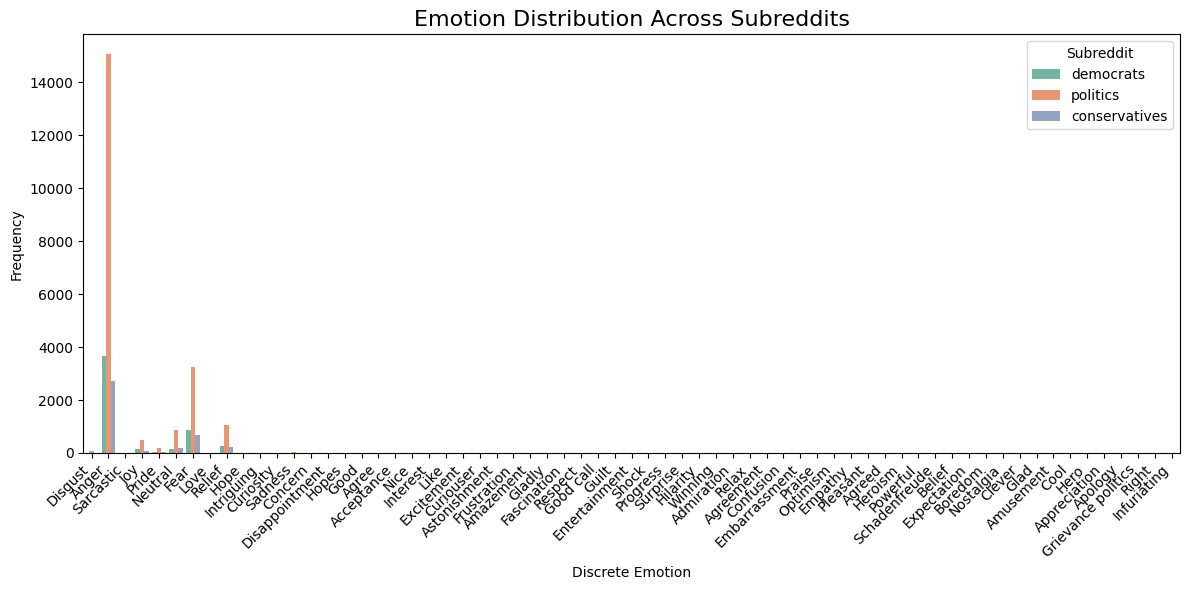

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# 1. Emotion Distribution
if 'discrete_emotion' in df_clean.columns and 'subreddit' in df_clean.columns:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df_clean, x='discrete_emotion', hue='subreddit', palette='Set2')
    plt.title('Emotion Distribution Across Subreddits', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Frequency')
    plt.xlabel('Discrete Emotion')
    plt.legend(title='Subreddit')
    plt.tight_layout()
    plt.show()
else:
    print("Required columns for Emotion Distribution are missing.")

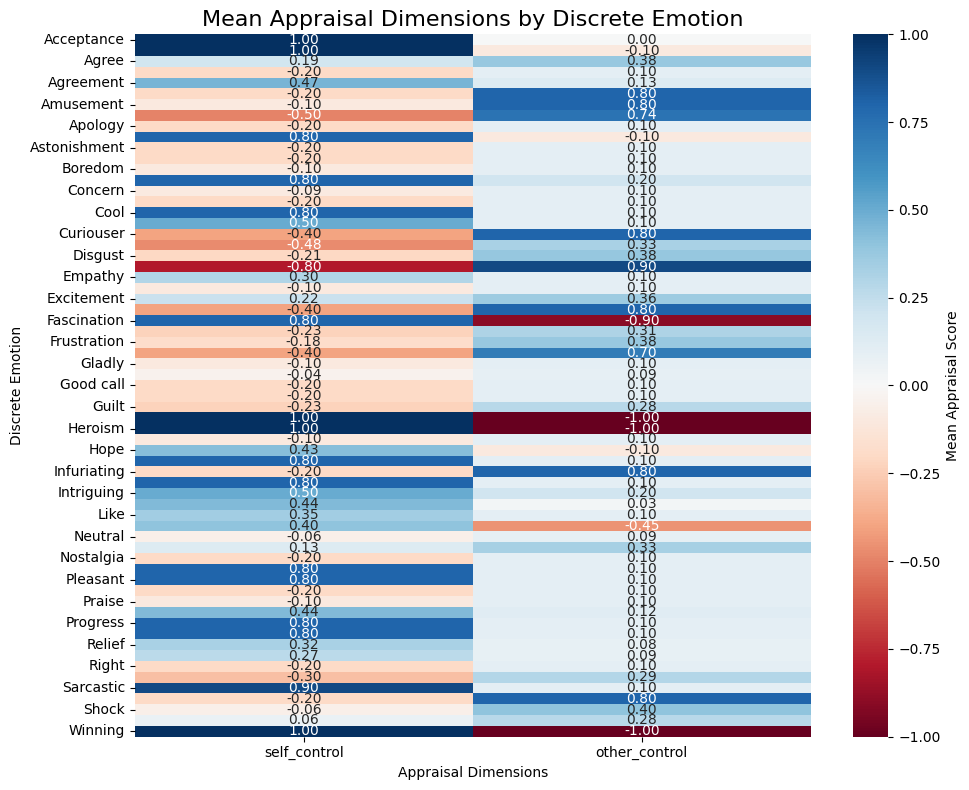

In [ ]:
# 2. Appraisal-Emotion Heatmap
appraisal_cols = ['goal_congruence', 'certainty', 'self_control', 'other_control']
available_appraisal = [c for c in appraisal_cols if c in df_clean.columns]

if 'discrete_emotion' in df_clean.columns and available_appraisal:
    emotion_appraisal_mean = df_clean.groupby('discrete_emotion')[available_appraisal].mean()

    plt.figure(figsize=(10, 8))
    sns.heatmap(emotion_appraisal_mean, annot=True, cmap='RdBu', center=0, fmt='.2f', cbar_kws={'label': 'Mean Appraisal Score'})
    plt.title('Mean Appraisal Dimensions by Discrete Emotion', fontsize=16)
    plt.ylabel('Discrete Emotion')
    plt.xlabel('Appraisal Dimensions')
    plt.tight_layout()
    plt.show()
else:
    print("Required columns for Appraisal-Emotion Heatmap are missing.")

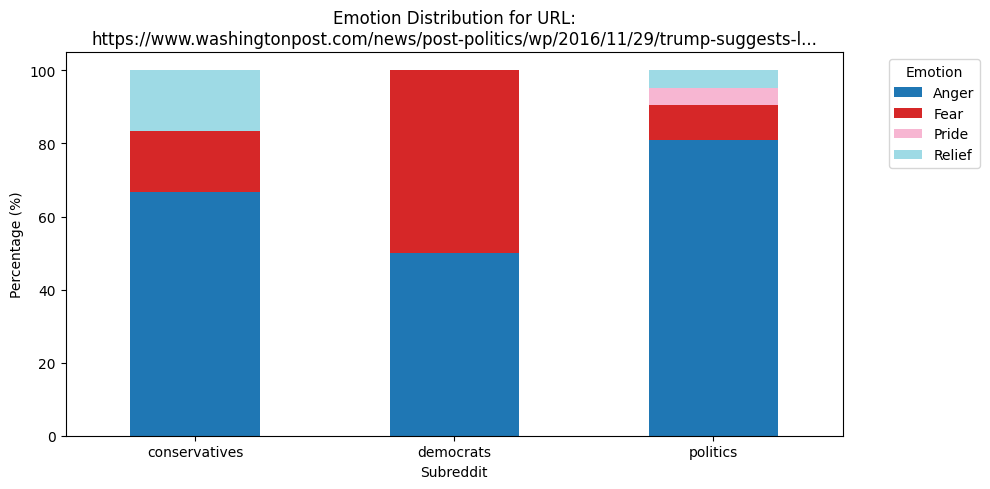

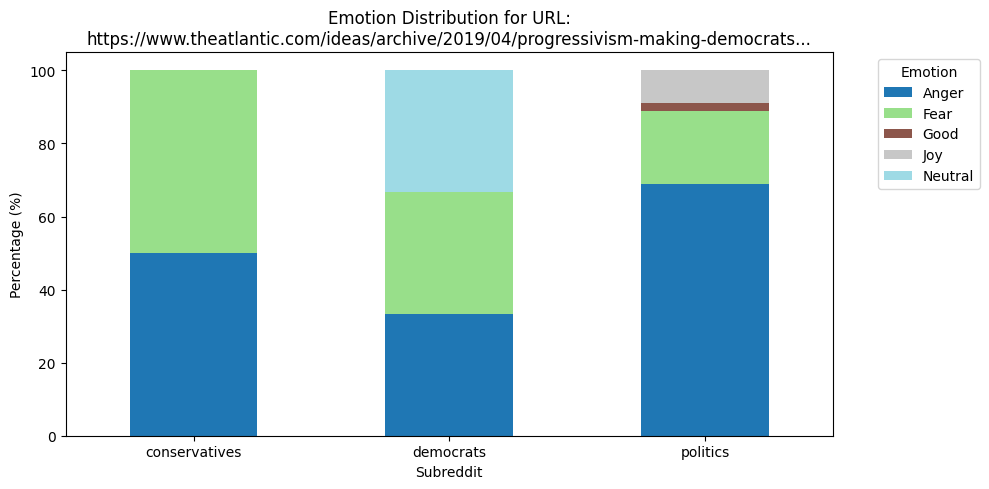

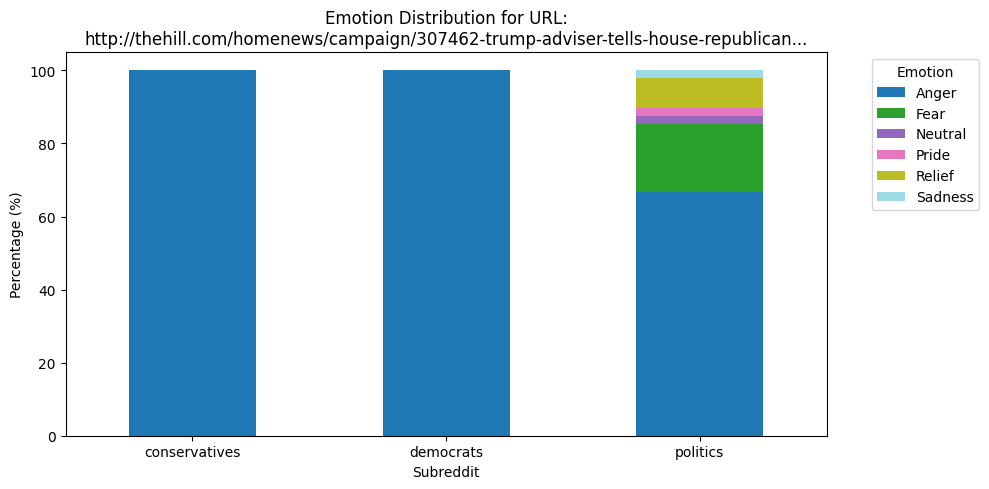

In [ ]:
# 3. The Stimulus-Response Test
if 'anchor_url' in df_clean.columns and 'subreddit' in df_clean.columns and 'discrete_emotion' in df_clean.columns:
    # Find URLs present in all 3 subreddits
    url_sub_counts = df_clean.groupby('anchor_url')['subreddit'].nunique()
    shared_urls = url_sub_counts[url_sub_counts == 3].index

    if len(shared_urls) > 0:
        # Filter for these URLs and find the top 3 by total comment count
        shared_df = df_clean[df_clean['anchor_url'].isin(shared_urls)]
        top_urls = shared_df['anchor_url'].value_counts().head(3).index

        for url in top_urls:
            url_data = df_clean[df_clean['anchor_url'] == url]
            emotion_counts = url_data.groupby(['subreddit', 'discrete_emotion']).size().unstack(fill_value=0)

            # Convert to percentages
            emotion_pct = emotion_counts.div(emotion_counts.sum(axis=1), axis=0) * 100

            emotion_pct.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='tab20')
            plt.title(f'Emotion Distribution for URL:\n{url[:80]}...')
            plt.ylabel('Percentage (%)')
            plt.xlabel('Subreddit')
            plt.legend(title='Emotion', bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.xticks(rotation=0)
            plt.tight_layout()
            plt.show()
    else:
        print("No URLs found that are shared across all three subreddits.")
else:
    print("Required columns for Stimulus-Response Test are missing.")

In [ ]:
# 4. Statistical Validation
if 'discrete_emotion' in df_clean.columns and 'subreddit' in df_clean.columns:
    # Create a contingency table
    contingency_table = pd.crosstab(df_clean['subreddit'], df_clean['discrete_emotion'])

    # Run Chi-squared test
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    print("--- Chi-Squared Test of Independence ---")
    print(f"Chi2 Statistic: {chi2:.4f}")
    print(f"p-value: {p:.4e}")
    print(f"Degrees of Freedom: {dof}")
    if p < 0.05:
        print("Result: Significant dependent relationship between Subreddit and Discrete Emotion.")
    else:
        print("Result: No significant dependent relationship found.")

--- Chi-Squared Test of Independence ---
Chi2 Statistic: 151.2395
p-value: 7.8692e-02
Degrees of Freedom: 128
Result: No significant dependent relationship found.


In [ ]:
# 5. Qualitative Sampling
if 'discrete_emotion' in df_clean.columns and 'subreddit' in df_clean.columns:
    text_col = 'body' if 'body' in df_clean.columns else 'text'
    rationale_col = 'rationale' if 'rationale' in df_clean.columns else None

    if text_col in df_clean.columns:
        subreddits = df_clean['subreddit'].dropna().unique()
        emotions_to_sample = ['anger', 'fear']

        for sub in subreddits:
            print(f"\n{'='*60}\nQualitative Samples for Subreddit: {sub.upper()}\n{'='*60}")
            sub_data = df_clean[df_clean['subreddit'] == sub]

            for emotion in emotions_to_sample:
                # Standardize emotion string matching to be safe
                emo_data = sub_data[sub_data['discrete_emotion'].astype(str).str.lower() == emotion]

                if not emo_data.empty:
                    sample = emo_data.sample(1, random_state=42).iloc[0]
                    print(f"\n--- Emotion: {emotion.capitalize()} ---")
                    print(f"Comment: {sample[text_col]}")
                    if rationale_col and pd.notna(sample[rationale_col]):
                        print(f"Rationale: {sample[rationale_col]}")
                else:
                    print(f"\n--- Emotion: {emotion.capitalize()} ---")
                    print(f"No samples found for {emotion} in r/{sub}.")
    else:
        print("Text column (e.g., 'body' or 'text') not found for qualitative sampling.")


Qualitative Samples for Subreddit: DEMOCRATS

--- Emotion: Anger ---
Comment: Good old Breitbart.com Land of the angry..., ...and the home of the naive.
Rationale: The author perceives a powerful adversary (Breitbart.com) acting deliberately against their goals with little recourse, driving anger.

--- Emotion: Fear ---
Comment: Well, there are two BLM’s. The one who grabbed the website and made money, and the movement. Two different entities.
Rationale: The author is concerned about the potential for two entities with different goals to coexist under the same name, potentially leading to confusion and misdirection.

Qualitative Samples for Subreddit: POLITICS

--- Emotion: Anger ---
Comment: People literally are feeling worse off in many places. Minimum wage hasn't moved for decades. Shit sucks for a lot of people. Dems are just turning into republicans and blaming lazy voters. They will keep losing if they do that. Trump was trying to get every last vote. He said anything, went anyw

### Longitudinal Cognitive Signature Analysis

Tracking appraisal shifts across political eras, visualizing the 'Agency Flip', and calculating the Polarization Index over time.

Data distribution by Political Era:
political_era
Pre-Election 2024         25509
Post-Inauguration 2025     3932
Transition Period           888
Name: count, dtype: int64


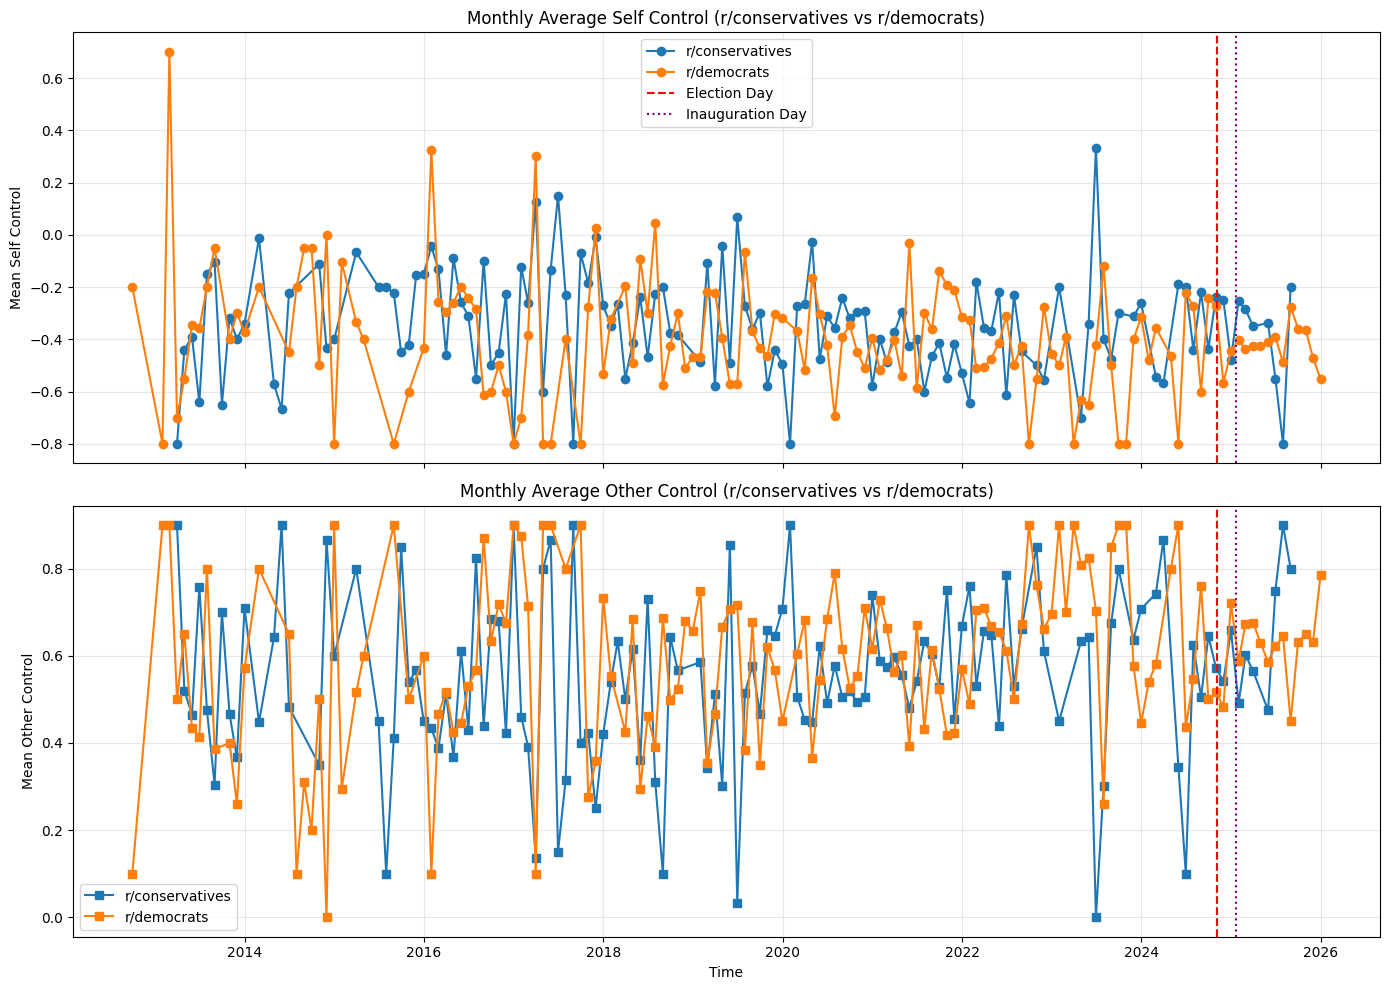

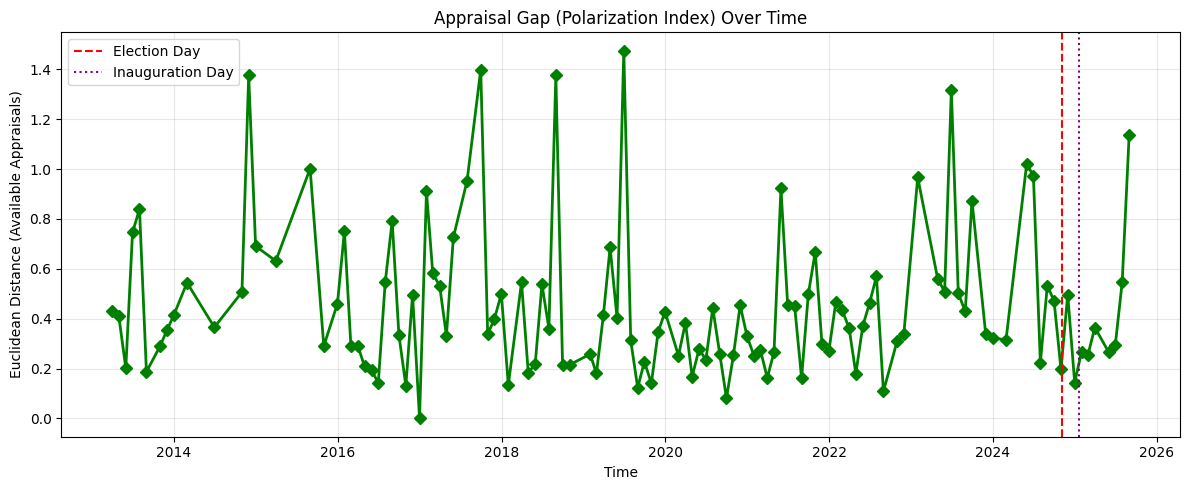


--- Top 3 Months by Appraisal Gap (Polarization Index) ---

Month: 2019-06
Top 3 Anchor URLs (Trigger Events):

Month: 2017-09
Top 3 Anchor URLs (Trigger Events):

Month: 2018-08
Top 3 Anchor URLs (Trigger Events):

--- Statistical Trend Test (Linear Regression) ---
Slope: -1.046583e-05
p-value: 6.3463e-01
Result: No significant trend in the Appraisal Gap over time.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import euclidean
from scipy.stats import linregress

if 'created_utc' in df_clean.columns:
    df_time = df_clean.dropna(subset=['created_utc']).copy()

    if not df_time.empty:
        # 1. Term Categorization
        election_date = pd.to_datetime('2024-11-05')
        inauguration_date = pd.to_datetime('2025-01-20')

        def get_era(date):
            if date < election_date:
                return 'Pre-Election 2024'
            elif date < inauguration_date:
                return 'Transition Period'
            else:
                return 'Post-Inauguration 2025'

        df_time['political_era'] = df_time['created_utc'].apply(get_era)
        print("Data distribution by Political Era:")
        print(df_time['political_era'].value_counts())

        # 2. Monthly Aggregation
        df_time.set_index('created_utc', inplace=True)
        cols_to_agg = [c for c in ['agency', 'goal_congruence', 'self_control', 'other_control'] if c in df_time.columns]
        if cols_to_agg:
            monthly_agg = df_time.groupby(['subreddit', pd.Grouper(freq='ME')])[cols_to_agg].mean().reset_index()
            monthly_agg.rename(columns={'created_utc': 'month'}, inplace=True)

            # 3. The 'Agency Flip' Visualization (Dynamic fallback if original columns missing)
            if len(cols_to_agg) >= 2:
                plot_col1 = cols_to_agg[0]
                plot_col2 = cols_to_agg[1]

                fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

                for sub in ['conservatives', 'democrats']:
                    sub_data = monthly_agg[monthly_agg['subreddit'] == sub]
                    if not sub_data.empty:
                        axes[0].plot(sub_data['month'], sub_data[plot_col1], marker='o', label=f'r/{sub}')
                        axes[1].plot(sub_data['month'], sub_data[plot_col2], marker='s', label=f'r/{sub}')

                for ax in axes:
                    ax.axvline(election_date, color='red', linestyle='--', label='Election Day' if ax == axes[0] else "")
                    ax.axvline(inauguration_date, color='purple', linestyle=':', label='Inauguration Day' if ax == axes[0] else "")
                    ax.legend()
                    ax.grid(True, alpha=0.3)

                axes[0].set_title(f"Monthly Average {plot_col1.replace('_', ' ').title()} (r/conservatives vs r/democrats)")
                axes[0].set_ylabel(f"Mean {plot_col1.replace('_', ' ').title()}")
                axes[1].set_title(f"Monthly Average {plot_col2.replace('_', ' ').title()} (r/conservatives vs r/democrats)")
                axes[1].set_ylabel(f"Mean {plot_col2.replace('_', ' ').title()}")
                axes[1].set_xlabel('Time')
                plt.tight_layout()
                plt.show()
            else:
                print("Not enough appraisal columns available for the visualization.")
        else:
             print("No appraisal columns found for monthly aggregation.")

        # 4. Appraisal Gap Over Time
        available_appraisal = [col for col in APPRAISAL_COLS if col in df_time.columns]
        if available_appraisal:
            monthly_appraisal = df_time.groupby(['subreddit', pd.Grouper(freq='ME')])[available_appraisal].mean().reset_index()
            monthly_appraisal.rename(columns={'created_utc': 'month'}, inplace=True)

            gaps = []
            months = monthly_appraisal['month'].unique()

            for m in months:
                m_data = monthly_appraisal[monthly_appraisal['month'] == m]
                cons = m_data[m_data['subreddit'] == 'conservatives']
                dems = m_data[m_data['subreddit'] == 'democrats']

                if not cons.empty and not dems.empty:
                    cons_vec = cons[available_appraisal].iloc[0].values
                    dems_vec = dems[available_appraisal].iloc[0].values
                    # Filter out NaNs
                    mask = ~np.isnan(cons_vec) & ~np.isnan(dems_vec)
                    if mask.any():
                        dist = euclidean(cons_vec[mask], dems_vec[mask])
                        gaps.append({'month': m, 'appraisal_gap': dist})

            gap_df = pd.DataFrame(gaps)

            if not gap_df.empty:
                gap_df['month_ts'] = gap_df['month']
                plt.figure(figsize=(12, 5))
                plt.plot(gap_df['month_ts'], gap_df['appraisal_gap'], marker='D', color='green', linewidth=2)
                plt.axvline(election_date, color='red', linestyle='--', label='Election Day')
                plt.axvline(inauguration_date, color='purple', linestyle=':', label='Inauguration Day')
                plt.title('Appraisal Gap (Polarization Index) Over Time')
                plt.ylabel('Euclidean Distance (Available Appraisals)')
                plt.xlabel('Time')
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()

                # 5. Event Analysis
                top_3_months = gap_df.nlargest(3, 'appraisal_gap')['month'].tolist()
                print("\n--- Top 3 Months by Appraisal Gap (Polarization Index) ---")

                for m in top_3_months:
                    print(f"\nMonth: {m.strftime('%Y-%m')}")
                    m_start = m
                    m_end = m_start + pd.offsets.MonthEnd(0)
                    m_events = df_clean[(df_clean['created_utc'] >= m_start) & (df_clean['created_utc'] <= m_end)]

                    if 'anchor_url' in m_events.columns:
                        top_urls = m_events['anchor_url'].value_counts().head(3)
                        print("Top 3 Anchor URLs (Trigger Events):")
                        for url, count in top_urls.items():
                            print(f" - {url} ({count} comments)")
                    else:
                        print("No anchor_url column available for event analysis.")

                # 6. Statistical Trend Test
                if len(gap_df) > 2:
                    gap_df['time_idx'] = (gap_df['month_ts'] - gap_df['month_ts'].min()).dt.days
                    slope, intercept, r_value, p_value, std_err = linregress(gap_df['time_idx'], gap_df['appraisal_gap'])

                    print("\n--- Statistical Trend Test (Linear Regression) ---")
                    print(f"Slope: {slope:.6e}")
                    print(f"p-value: {p_value:.4e}")
                    if p_value < 0.05:
                        trend = "widening" if slope > 0 else "narrowing"
                        print(f"Result: The Appraisal Gap is significantly {trend} over time.")
                    else:
                        print("Result: No significant trend in the Appraisal Gap over time.")
                else:
                     print("\nNot enough monthly data points to run a trend test.")
            else:
                print("Not enough overlapping data to calculate the Appraisal Gap between conservatives and democrats.")
        else:
             print("No appraisal columns found for Gap analysis.")
    else:
        print("No valid timestamps available after dropping NaNs.")
else:
    print("'created_utc' column missing from dataframe.")

### Competitive Model Evaluation

Testing the Null Hypothesis by comparing a Baseline Model (Sentiment Only) to a Cognitive Model (Appraisal Dimensions) using OLS regression.


--- Competitive Model Evaluation Summary ---


,Group,Model,R-squared,Adj. R-squared,AIC,BIC
0,Overall,Baseline (Sentiment),0.0021,0.0021,128003.0707,128019.6727
1,Overall,Cognitive (Appraisals),0.0184,0.0182,127521.3962,127571.2019
2,r/democrats,Baseline (Sentiment),0.0000,-0.0002,16206.7463,16219.8227
3,r/democrats,Cognitive (Appraisals),0.0083,0.0073,16172.3550,16211.5840
4,r/politics,Baseline (Sentiment),0.0022,0.0021,91320.3675,91336.2558
5,r/politics,Cognitive (Appraisals),0.0236,0.0234,90876.4259,90924.0908
6,r/conservatives,Baseline (Sentiment),0.0000,-0.0003,9347.1019,9359.6005
7,r/conservatives,Cognitive (Appraisals),0.0043,0.0030,9338.5136,9376.0095


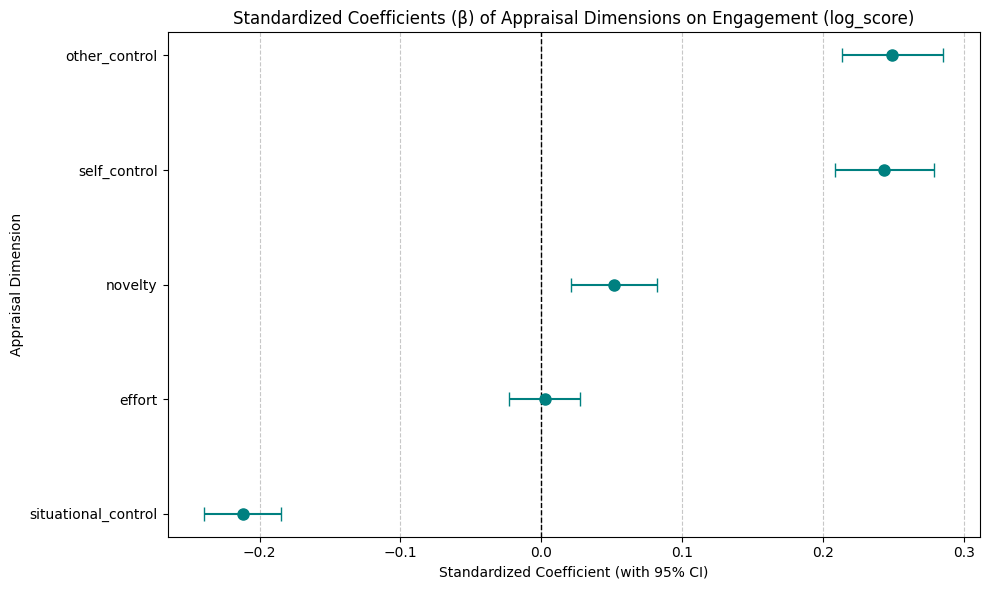


--- Conclusion for Report ---
The Cognitive Model significantly outperforms the Baseline Model (ΔAIC = 481.67, ΔAdj.R² = 0.0162).
There are strong statistical grounds to REJECT the Null Hypothesis (H0). Cognitive appraisals provide a better predictive signature for engagement than simple sentiment.


In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Ensure APPRAISAL_COLS is defined
appraisal_dimensions = ['self_control', 'other_control', 'situational_control', 'novelty', 'effort', 'agency', 'goal_congruence', 'certainty']
available_appraisal = [c for c in appraisal_dimensions if c in df_clean.columns]

# Prepare dataset for modeling
req_cols = ['log_score', 'sentiment_score', 'subreddit'] + available_appraisal
df_model = df_clean[req_cols].copy()

# Safely handle -inf from log1p(-1) scores by replacing with NaN before dropping
df_model.replace([np.inf, -np.inf], np.nan, inplace=True)
df_model.dropna(subset=req_cols, inplace=True)

if not df_model.empty and len(available_appraisal) > 0:
    results = []

    # Helper function to run and compare models
    def evaluate_models(data, group_name):
        y = data['log_score']

        # Baseline Model: Sentiment Only
        X_base = sm.add_constant(data[['sentiment_score']])
        model_base = sm.OLS(y, X_base).fit()

        # Cognitive Model: Appraisal Only
        X_cog = sm.add_constant(data[available_appraisal])
        model_cog = sm.OLS(y, X_cog).fit()

        results.append({
            'Group': group_name,
            'Model': 'Baseline (Sentiment)',
            'R-squared': model_base.rsquared,
            'Adj. R-squared': model_base.rsquared_adj,
            'AIC': model_base.aic,
            'BIC': model_base.bic
        })

        results.append({
            'Group': group_name,
            'Model': 'Cognitive (Appraisals)',
            'R-squared': model_cog.rsquared,
            'Adj. R-squared': model_cog.rsquared_adj,
            'AIC': model_cog.aic,
            'BIC': model_cog.bic
        })
        return model_base, model_cog

    # 1-3. Overall Model Evaluation
    _, overall_model_cog = evaluate_models(df_model, 'Overall')

    # 4. Subreddit-Specific Analysis
    subreddits = df_model['subreddit'].unique()
    for sub in subreddits:
        evaluate_models(df_model[df_model['subreddit'] == sub], f'r/{sub}')

    # Display Summary Table
    results_df = pd.DataFrame(results)
    print("\n--- Competitive Model Evaluation Summary ---")
    display(results_df.round(4))

    # 5. Visualization of Effect Sizes (Forest Plot for Cognitive Model)
    # Standardize predictors to get comparable beta weights
    scaler = StandardScaler()
    X_cog_std = pd.DataFrame(scaler.fit_transform(df_model[available_appraisal]), columns=available_appraisal, index=df_model.index)
    X_cog_std = sm.add_constant(X_cog_std)
    model_cog_std = sm.OLS(df_model['log_score'], X_cog_std).fit()

    # Extract coefficients and confidence intervals (excluding constant)
    coefs = model_cog_std.params.drop('const')
    conf_ints = model_cog_std.conf_int().drop('const')
    errors = coefs - conf_ints[0]

    # Sort for better visualization
    coefs_sorted = coefs.sort_values()
    errors_sorted = errors[coefs_sorted.index]

    plt.figure(figsize=(10, 6))
    plt.errorbar(coefs_sorted.values, coefs_sorted.index, xerr=errors_sorted.values, fmt='o', color='teal', capsize=5, markersize=8)
    plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
    plt.title('Standardized Coefficients (β) of Appraisal Dimensions on Engagement (log_score)')
    plt.xlabel('Standardized Coefficient (with 95% CI)')
    plt.ylabel('Appraisal Dimension')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # 6. Conclusion for Report
    overall_base = results_df[(results_df['Group'] == 'Overall') & (results_df['Model'] == 'Baseline (Sentiment)')].iloc[0]
    overall_cog = results_df[(results_df['Group'] == 'Overall') & (results_df['Model'] == 'Cognitive (Appraisals)')].iloc[0]

    aic_diff = overall_base['AIC'] - overall_cog['AIC']
    r2_diff = overall_cog['Adj. R-squared'] - overall_base['Adj. R-squared']

    print("\n--- Conclusion for Report ---")
    if aic_diff > 10 and r2_diff > 0:
        print(f"The Cognitive Model significantly outperforms the Baseline Model (ΔAIC = {aic_diff:.2f}, ΔAdj.R² = {r2_diff:.4f}).")
        print("There are strong statistical grounds to REJECT the Null Hypothesis (H0). Cognitive appraisals provide a better predictive signature for engagement than simple sentiment.")
    else:
        print(f"The Cognitive Model does not definitively outperform the Baseline Model (ΔAIC = {aic_diff:.2f}, ΔAdj.R² = {r2_diff:.4f}).")
        print("We CANNOT reject the Null Hypothesis (H0) based on these overall metrics.")
else:
    print("Insufficient data or missing columns to run the model evaluation.")

### Appraisal Taxonomy Expansion: Effort and Novelty

Deep diving into the cognitive signatures of engagement, focusing on how 'Effort' and 'Novelty' shape the discourse.

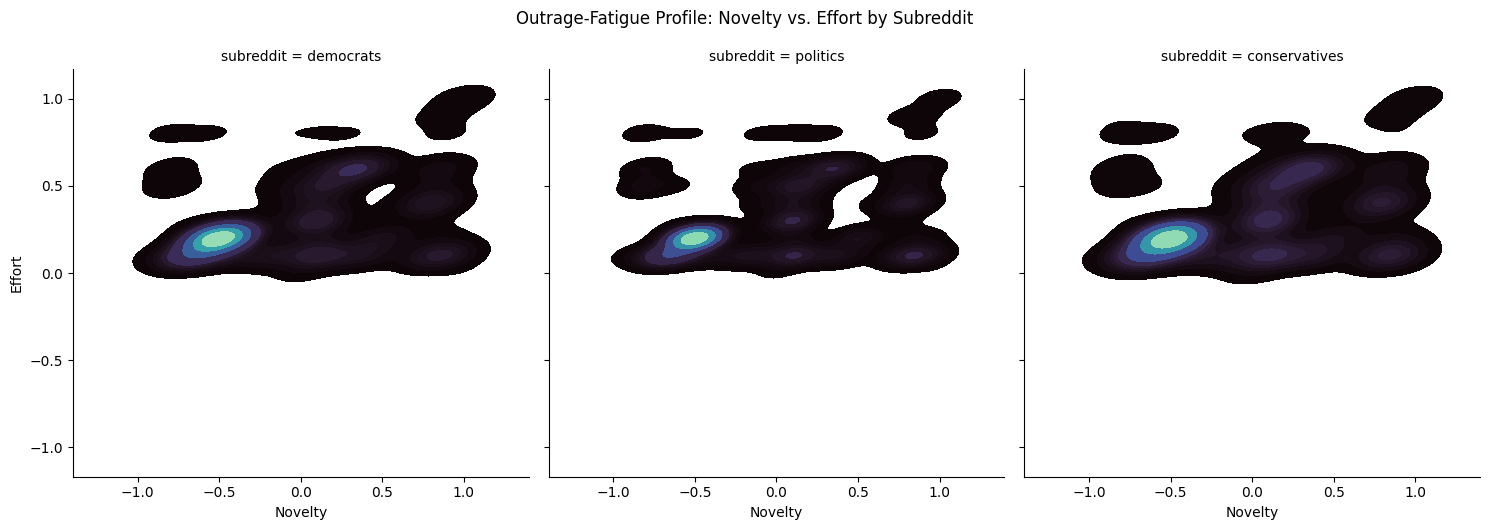

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import linregress

# Ensure we have the necessary columns
req_cols = ['novelty', 'effort', 'subreddit']
if all(col in df_clean.columns for col in req_cols):
    # 1. The Outrage-Fatigue Profile (2D Density Plot)
    df_plot = df_clean.dropna(subset=req_cols)
    g = sns.FacetGrid(df_plot, col="subreddit", col_wrap=3, height=5)
    g.map_dataframe(sns.kdeplot, x="novelty", y="effort", fill=True, cmap="mako", thresh=0.05)
    g.set_axis_labels("Novelty", "Effort")
    g.fig.suptitle('Outrage-Fatigue Profile: Novelty vs. Effort by Subreddit', y=1.05)
    plt.show()
else:
    print("Required columns for Outrage-Fatigue Profile are missing.")

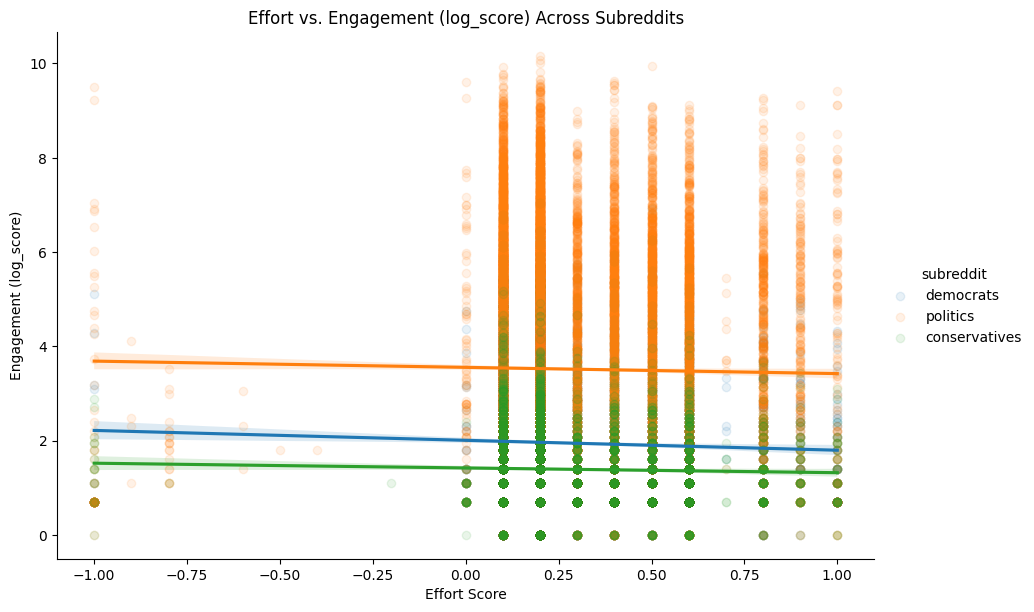

In [ ]:
# 2. Effort vs. Engagement
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Opt-in to the future behavior to suppress the warning
pd.set_option('future.no_silent_downcasting', True)

if 'effort' in df_clean.columns and 'log_score' in df_clean.columns and 'subreddit' in df_clean.columns:
    # Clean infs and NaNs
    df_eng = df_clean.replace([np.inf, -np.inf], np.nan).infer_objects(copy=False).dropna(subset=['effort', 'log_score', 'subreddit'])

    sns.lmplot(data=df_eng, x='effort', y='log_score', hue='subreddit', height=6, aspect=1.5, scatter_kws={'alpha': 0.1})
    plt.title('Effort vs. Engagement (log_score) Across Subreddits')
    plt.xlabel('Effort Score')
    plt.ylabel('Engagement (log_score)')
    plt.show()
else:
    print("Required columns for Effort vs. Engagement are missing.")

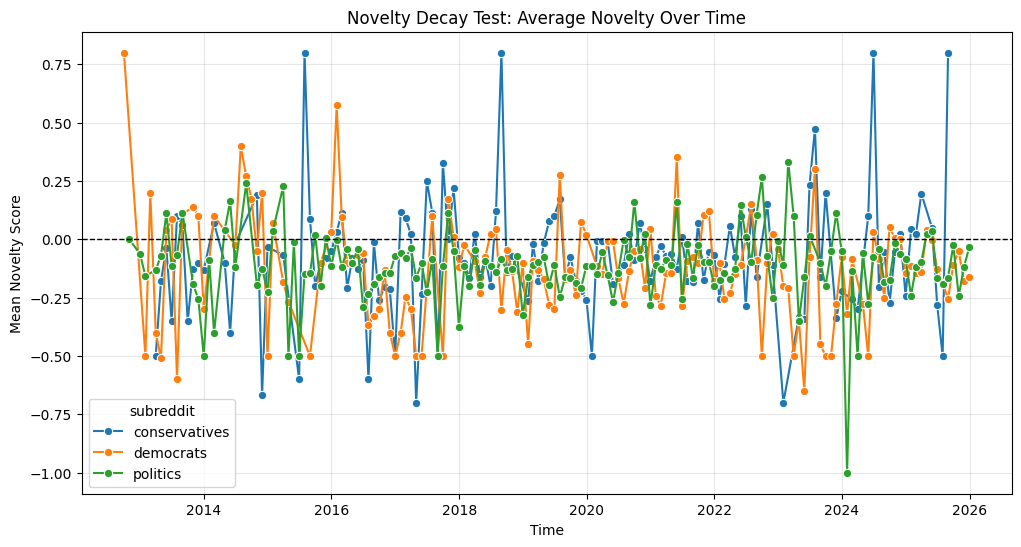


--- Novelty Decay Trend Test ---
r/conservatives: Trend = Increasing | Slope = 2.139160e-05 | p-value = 0.2226 (Not Significant)
r/democrats: Trend = Decreasing (Decay/Fatigue) | Slope = -2.147665e-05 | p-value = 0.1292 (Not Significant)
r/politics: Trend = Increasing | Slope = 3.453351e-07 | p-value = 0.9708 (Not Significant)


In [ ]:
# 3. Novelty Decay Test
if 'novelty' in df_clean.columns and 'created_utc' in df_clean.columns and 'subreddit' in df_clean.columns:
    df_time = df_clean.dropna(subset=['created_utc', 'novelty', 'subreddit']).copy()

    if not df_time.empty:
        df_time.set_index('created_utc', inplace=True)
        monthly_novelty = df_time.groupby(['subreddit', pd.Grouper(freq='ME')])['novelty'].mean().reset_index()
        monthly_novelty.rename(columns={'created_utc': 'month'}, inplace=True)

        plt.figure(figsize=(12, 6))
        sns.lineplot(data=monthly_novelty, x='month', y='novelty', hue='subreddit', marker='o')
        plt.title('Novelty Decay Test: Average Novelty Over Time')
        plt.xlabel('Time')
        plt.ylabel('Mean Novelty Score')
        plt.axhline(0, color='black', linestyle='--', linewidth=1)
        plt.grid(True, alpha=0.3)
        plt.show()

        # Statistical Test for Decay
        print("\n--- Novelty Decay Trend Test ---")
        for sub in monthly_novelty['subreddit'].unique():
            sub_data = monthly_novelty[monthly_novelty['subreddit'] == sub].dropna()
            if len(sub_data) > 2:
                time_idx = (sub_data['month'] - sub_data['month'].min()).dt.days
                slope, intercept, r_val, p_val, std_err = linregress(time_idx, sub_data['novelty'])
                trend = "Decreasing (Decay/Fatigue)" if slope < 0 else "Increasing"
                sig = "Significant" if p_val < 0.05 else "Not Significant"
                print(f"r/{sub}: Trend = {trend} | Slope = {slope:.6e} | p-value = {p_val:.4f} ({sig})")
            else:
                print(f"r/{sub}: Not enough data points.")
else:
    print("Required columns for Novelty Decay Test are missing.")

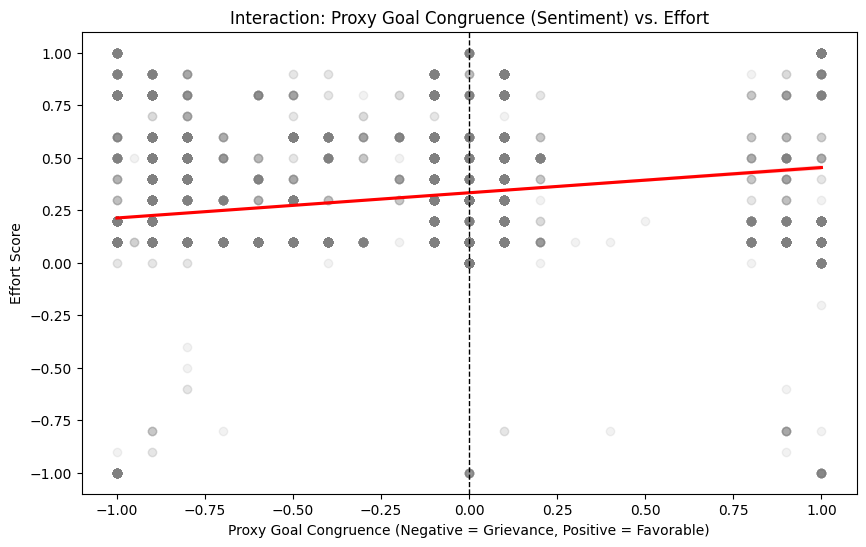

In [ ]:
# 4. Interaction with Goal Congruence (Proxy)
# Since goal_congruence is missing, we use sentiment_score as a proxy
if 'effort' in df_clean.columns and 'sentiment_score' in df_clean.columns:
    df_int = df_clean.dropna(subset=['effort', 'sentiment_score']).copy()
    df_int['proxy_goal_congruence'] = df_int['sentiment_score']

    plt.figure(figsize=(10, 6))
    sns.regplot(data=df_int, x='proxy_goal_congruence', y='effort', scatter_kws={'alpha': 0.1, 'color': 'gray'}, line_kws={'color': 'red'})
    plt.title('Interaction: Proxy Goal Congruence (Sentiment) vs. Effort')
    plt.xlabel('Proxy Goal Congruence (Negative = Grievance, Positive = Favorable)')
    plt.ylabel('Effort Score')
    plt.axvline(0, color='black', linestyle='--', linewidth=1)
    plt.show()
else:
    print("Required columns for Proxy Goal Congruence Interaction are missing.")

In [ ]:
# 5. Summary Table
if 'discrete_emotion' in df_clean.columns and 'novelty' in df_clean.columns and 'effort' in df_clean.columns:
    emo_summary = df_clean.groupby('discrete_emotion')[['novelty', 'effort']].agg(['mean', 'median', 'count'])
    # Sort by highest mean effort to lowest
    emo_summary = emo_summary.sort_values(by=('effort', 'mean'), ascending=False)

    print("\n--- Cognitive Signature: Novelty and Effort by Emotion ---")
    display(emo_summary)
else:
    print("Required columns for Emotion Summary Table are missing.")


--- Cognitive Signature: Novelty and Effort by Emotion ---


novelty              effort             
                    mean median count   mean median count
discrete_emotion                                         
Hero                 1.0    1.0     1    1.0    1.0     1
Heroism              1.0    1.0     1    1.0    1.0     1
Winning              1.0    1.0     1    1.0    1.0     1
Nostalgia            0.8    0.8     1    0.9    0.9     1
Admiration          -0.1   -0.1     1    0.8    0.8     1
...                  ...    ...   ...    ...    ...   ...
Infuriating          0.8    0.8     1    0.1    0.1     1
Sarcastic            0.5    0.5     1    0.1    0.1     1
Praise               0.1    0.1     1    0.1    0.1     1
Schadenfreude        0.4    0.4     1    0.1    0.1     1
Acceptance           0.0    0.0     1    0.0    0.0     1

[65 rows x 6 columns]